## **01_Limpieza_de_datos**

Desarrollado por: Ing. M. Wara López L.

### Importación de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Carga del dataset

In [2]:
df = pd.read_csv('dataset_batteries_to_use.csv')

In [3]:
df.head()

,Edad_Bateria,Horas_Uso_Diario,Usuario_Gamer,Capacidad_Diseño,Ciclos_Carga,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio,Capacidad_Carga_Completa,Salud_Bateria
0,5,9.797617,0,57884,1267,64.587764,43.887115,84.366245,35.645636,44961.935220,76.923383
1,9,7.101557,0,63824,13986,45.542182,36.534144,80.629042,31.782432,46619.665590,73.496153
2,9,10.085255,0,79414,1500,64.640516,52.238349,87.853504,32.122879,63343.419989,-10.000000
3,5,7.946047,0,61142,1153,55.095724,30.535647,69.686012,30.371133,50407.438833,79.742100
4,-3,9.628460,0,50956,6886,60.145756,36.749489,64.734123,27.536232,34757.377982,67.882552


### Exploración inicial del dataset

In [4]:
df.shape

(1220, 11)

In [5]:
df.dtypes

Edad_Bateria                  int64
Horas_Uso_Diario            float64
Usuario_Gamer                 int64
Capacidad_Diseño              int64
Ciclos_Carga                  int64
Uso_CPU                     float64
Uso_GPU                     float64
Consumo_Energia             float64
Temperatura_Promedio        float64
Capacidad_Carga_Completa    float64
Salud_Bateria               float64
dtype: object

In [6]:
df["Usuario_Gamer"] = df["Usuario_Gamer"].astype("object")

In [7]:
df.dtypes

Edad_Bateria                  int64
Horas_Uso_Diario            float64
Usuario_Gamer                object
Capacidad_Diseño              int64
Ciclos_Carga                  int64
Uso_CPU                     float64
Uso_GPU                     float64
Consumo_Energia             float64
Temperatura_Promedio        float64
Capacidad_Carga_Completa    float64
Salud_Bateria               float64
dtype: object

In [8]:
df.describe()

,Edad_Bateria,Horas_Uso_Diario,Capacidad_Diseño,Ciclos_Carga,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio,Capacidad_Carga_Completa,Salud_Bateria
count,1220.000000,1220.000000,1220.000000,1220.000000,1142.000000,1164.000000,1166.000000,1170.000000,1220.000000,1164.000000
mean,6.765574,6.455593,61965.800820,1939.936066,61.227280,49.097107,120.143132,33.106340,41312.040844,81.651037
std,11.120230,3.149675,10130.455446,2978.978406,38.614224,38.893030,156.276314,25.673989,33236.472100,25.435351
min,-3.000000,1.002497,45002.000000,0.000000,9.151884,5.000000,20.133013,-20.000000,-79263.000000,-10.000000
25%,2.000000,3.734475,53208.000000,596.750000,35.525100,25.387978,54.774767,28.389994,39838.626893,74.668093
50%,5.000000,6.336366,61723.000000,1265.000000,53.248439,37.675857,71.131985,30.383585,49416.351879,81.771071
75%,7.000000,9.206696,70693.000000,1500.000000,69.617865,52.243811,90.197064,32.466739,59262.045880,92.868974
max,60.000000,11.986722,79959.000000,14978.000000,199.960415,178.901070,789.000000,150.000000,78634.214027,150.000000


### Detección de errores

In [9]:
# Conteo de valores nulos por variable
num_datos_nulos = df.isnull().sum()

print("📊 CONTEO DE DATOS NULOS:")
print("-" * 50)
print(num_datos_nulos)
print("-" * 50)
total_nulos = num_datos_nulos.sum()
print(f"TOTAL de valores nulos en todas las variables: {total_nulos}")

📊 CONTEO DE DATOS NULOS:
--------------------------------------------------
Edad_Bateria                 0
Horas_Uso_Diario             0
Usuario_Gamer                0
Capacidad_Diseño             0
Ciclos_Carga                 0
Uso_CPU                     78
Uso_GPU                     56
Consumo_Energia             54
Temperatura_Promedio        50
Capacidad_Carga_Completa     0
Salud_Bateria               56
dtype: int64
--------------------------------------------------
TOTAL de valores nulos en todas las variables: 294


In [10]:
# Definir la función para contar valores atípicos
def contar_valores_atipicos(columna):
    Q1 = columna.quantile(0.25)
    Q3 = columna.quantile(0.75)
    IQR = Q3 - Q1
    umbral_inferior = Q1 - 1.5 * IQR
    umbral_superior = Q3 + 1.5 * IQR
    valores_atipicos = ((columna < umbral_inferior) | (columna > umbral_superior)).sum()
    return valores_atipicos
# Lista de variables cuantitativas de tu dataset
variables_cuantitativas = df.select_dtypes(include=["int64","float64"]).columns
# Aplicar la función a cada variable
print("📊 CONTEO DE VALORES ATÍPICOS (OUTLIERS):")
print("-" * 50)
for variable in variables_cuantitativas:
    num_valores_atipicos = contar_valores_atipicos(df[variable])
    print(f"{variable:25} → {num_valores_atipicos:5} valores atípicos")

print("-" * 50)
total_atipicos = sum([contar_valores_atipicos(df[var]) for var in variables_cuantitativas])
print(f"TOTAL de valores atípicos en todas las variables: {total_atipicos}")

📊 CONTEO DE VALORES ATÍPICOS (OUTLIERS):
--------------------------------------------------
Edad_Bateria              →    67 valores atípicos
Horas_Uso_Diario          →     0 valores atípicos
Capacidad_Diseño          →     0 valores atípicos
Ciclos_Carga              →   124 valores atípicos
Uso_CPU                   →   118 valores atípicos
Uso_GPU                   →   127 valores atípicos
Consumo_Energia           →   125 valores atípicos
Temperatura_Promedio      →   126 valores atípicos
Capacidad_Carga_Completa  →   122 valores atípicos
Salud_Bateria             →    93 valores atípicos
--------------------------------------------------
TOTAL de valores atípicos en todas las variables: 902


In [11]:
duplicados = df.duplicated().sum()
print("📊 CONTEO DE DATOS DUPLICADOS:")
print("-" * 50)
print(f"TOTAL de valores duplicados: {duplicados}")

📊 CONTEO DE DATOS DUPLICADOS:
--------------------------------------------------
TOTAL de valores duplicados: 20


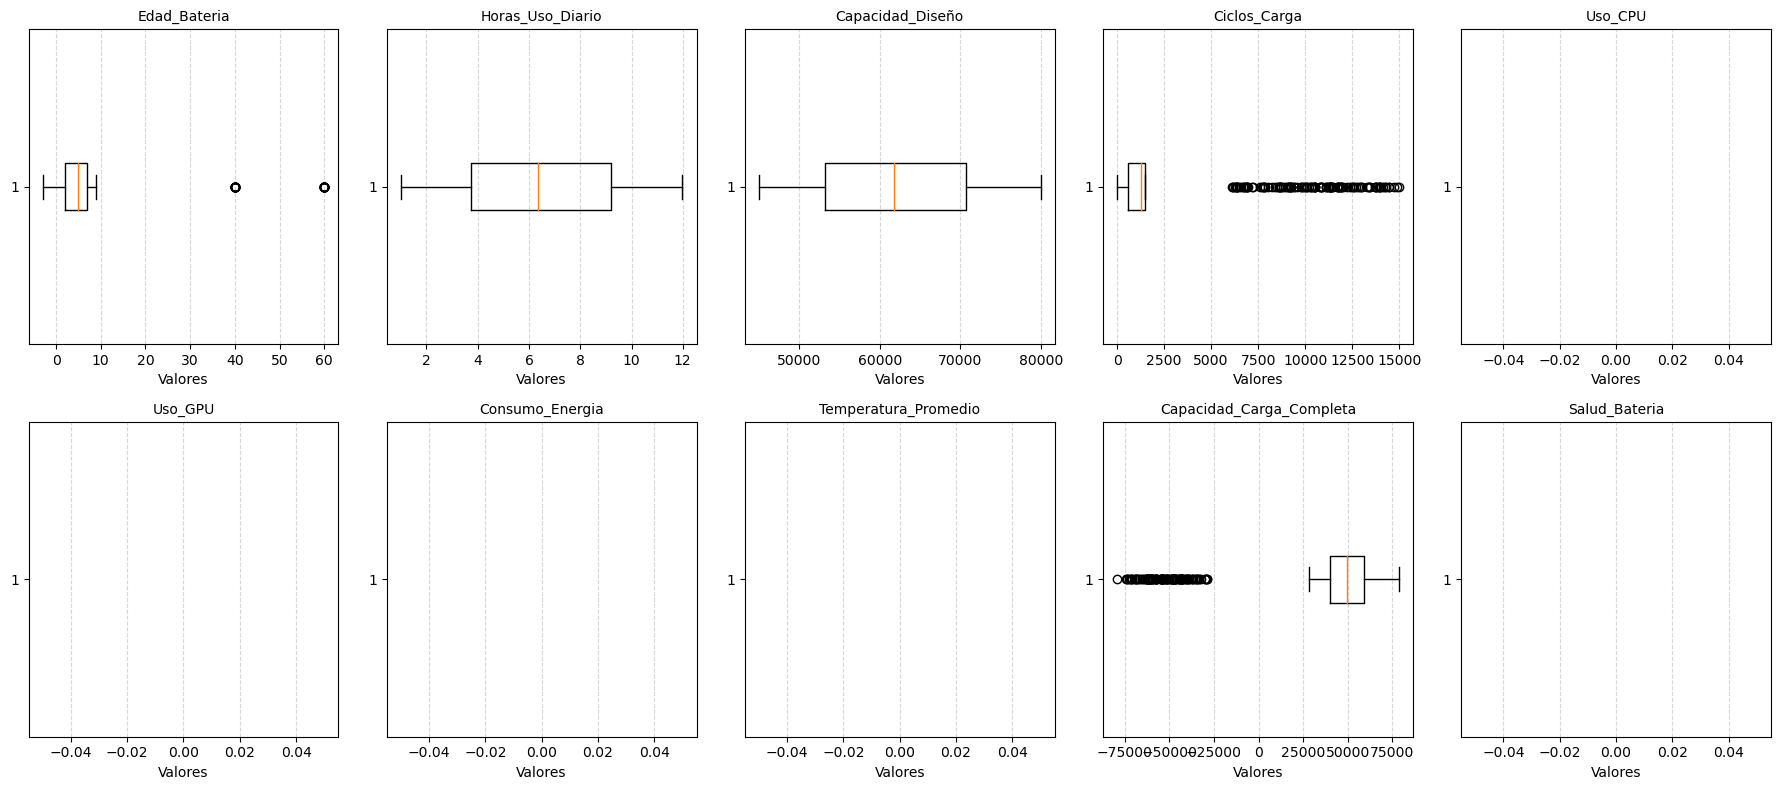

In [12]:
variables = [
    "Edad_Bateria",
    "Horas_Uso_Diario",
    "Capacidad_Diseño",
    "Ciclos_Carga",
    "Uso_CPU",
    "Uso_GPU",
    "Consumo_Energia",
    "Temperatura_Promedio",
    "Capacidad_Carga_Completa",
    "Salud_Bateria"
]

# Crear matriz de gráficos
fig, axes = plt.subplots( nrows=2,ncols=5,figsize=(18, 8))
axes = axes.flatten()
for i, variable in enumerate(variables):
    axes[i].boxplot(df[variable], vert=False)
    axes[i].set_title(variable, fontsize=10)
    axes[i].set_xlabel("Valores")
    axes[i].grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
df.groupby("Usuario_Gamer")[ ["Uso_CPU", "Uso_GPU", "Consumo_Energia", "Temperatura_Promedio"]].mean()

,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio
Usuario_Gamer,,,,
0,58.579273,45.314746,119.174834,32.706910
1,83.571207,81.700429,128.662523,36.601352


In [14]:
df[df["Ciclos_Carga"] > 1500]["Ciclos_Carga"].sort_values()

459      6117
359      6148
382      6179
908      6243
1149     6295
        ...  
354     14462
364     14469
752     14741
295     14903
16      14978
Name: Ciclos_Carga, Length: 124, dtype: int64

In [15]:
df[df["Consumo_Energia"] > 150]["Consumo_Energia"].sort_values()

794     304.0
970     313.0
853     315.0
589     318.0
151     318.0
        ...  
44      764.0
573     772.0
282     779.0
548     785.0
1031    789.0
Name: Consumo_Energia, Length: 125, dtype: float64

In [16]:
df[df["Salud_Bateria"] < 50]["Salud_Bateria"]

2      -10.0
27     -10.0
75     -10.0
87       0.0
118    -10.0
122    -10.0
123    -10.0
129    -10.0
164      0.0
169      0.0
181      0.0
187      0.0
205    -10.0
226    -10.0
248    -10.0
267    -10.0
312    -10.0
346    -10.0
352    -10.0
353      0.0
375      0.0
378    -10.0
387    -10.0
407      0.0
421      0.0
442    -10.0
458      0.0
471      0.0
475    -10.0
495    -10.0
520      0.0
568      0.0
607    -10.0
608    -10.0
634    -10.0
637    -10.0
679      0.0
695      0.0
699    -10.0
727    -10.0
732      0.0
749      0.0
761      0.0
767      0.0
788      0.0
803    -10.0
812      0.0
822    -10.0
830      0.0
852      0.0
897    -10.0
935    -10.0
1007   -10.0
1063     0.0
1079   -10.0
1109     0.0
1196   -10.0
Name: Salud_Bateria, dtype: float64

### Corrección de datos

In [17]:
# 1. Edad de batería
df.loc[(df["Edad_Bateria"] < 0) | (df["Edad_Bateria"] > 20), "Edad_Bateria"] = np.nan

# 2. Temperatura promedio
df.loc[(df["Temperatura_Promedio"] < 0) | (df["Temperatura_Promedio"] > 80), "Temperatura_Promedio"] = np.nan

# 3. Capacidad de carga completa negativa
mask = df["Capacidad_Carga_Completa"] < 0
valores = np.random.normal(
    df.loc[~mask, "Capacidad_Carga_Completa"].mean(),
    df.loc[~mask, "Capacidad_Carga_Completa"].std(),
    mask.sum()
)
df.loc[mask, "Capacidad_Carga_Completa"] = np.clip(
    valores,
    df.loc[~mask, "Capacidad_Carga_Completa"].min(),
    df.loc[~mask, "Capacidad_Carga_Completa"].max()
)

# 4. Salud de batería fuera de rango
df.loc[(df["Salud_Bateria"] < 0) | (df["Salud_Bateria"] > 100), "Salud_Bateria"] = np.nan

# 5. Uso CPU fuera de porcentaje válido
df.loc[(df["Uso_CPU"] < 0) | (df["Uso_CPU"] > 100), "Uso_CPU"] = np.nan

# 6. Uso GPU fuera de porcentaje válido
df.loc[(df["Uso_GPU"] < 0) | (df["Uso_GPU"] > 100), "Uso_GPU"] = np.nan

# 7. Ciclos de carga
mask = df["Ciclos_Carga"] > 1500
valores = np.random.normal(
    df.loc[~mask, "Ciclos_Carga"].mean(),
    df.loc[~mask, "Ciclos_Carga"].std(),
    mask.sum()
)
df.loc[mask, "Ciclos_Carga"] = np.clip(valores, 0, 1500)

# 8. Consumo energético extremo
df.loc[df["Consumo_Energia"] > 150, "Consumo_Energia"] = np.nan

# 9. Salud de batería igual a cero
df.loc[df["Salud_Bateria"] == 0, "Salud_Bateria"] = np.nan

### Imputación de datos

In [18]:
# Imputación por mediana
variables_mediana = [
    "Edad_Bateria",
    "Uso_CPU",
    "Uso_GPU",
    "Temperatura_Promedio"
]
for variable in variables_mediana:
    df[variable] = df[variable].fillna(df[variable].median())

# Imputación de Consumo_Energia mediante distribución normal
mask = df["Consumo_Energia"].isna()
valores = np.random.normal(
    df.loc[~mask, "Consumo_Energia"].mean(),
    df.loc[~mask, "Consumo_Energia"].std(),
    mask.sum()
)
df.loc[mask, "Consumo_Energia"] = np.clip(valores,df.loc[~mask, "Consumo_Energia"].min(),df.loc[~mask, "Consumo_Energia"].max())

# Imputación de Salud_Bateria basada en la capacidad retenida
mask = df["Salud_Bateria"].isna()
df.loc[mask, "Salud_Bateria"] = (df.loc[mask, "Capacidad_Carga_Completa"] /df.loc[mask, "Capacidad_Diseño"]) * 100
df["Salud_Bateria"] = df["Salud_Bateria"].clip(0, 100)

In [19]:
# Eliminar registros duplicados
df = df.drop_duplicates().reset_index(drop=True)

### Validación final

In [20]:
# Conteo de valores nulos por variable
num_datos_nulos = df.isnull().sum()

print("📊 CONTEO DE DATOS NULOS:")
print("-" * 50)
print(num_datos_nulos)
print("-" * 50)
total_nulos = num_datos_nulos.sum()
print(f"TOTAL de valores nulos en todas las variables: {total_nulos}")

📊 CONTEO DE DATOS NULOS:
--------------------------------------------------
Edad_Bateria                0
Horas_Uso_Diario            0
Usuario_Gamer               0
Capacidad_Diseño            0
Ciclos_Carga                0
Uso_CPU                     0
Uso_GPU                     0
Consumo_Energia             0
Temperatura_Promedio        0
Capacidad_Carga_Completa    0
Salud_Bateria               0
dtype: int64
--------------------------------------------------
TOTAL de valores nulos en todas las variables: 0


In [21]:
# Definir la función para contar valores atípicos
def contar_valores_atipicos(columna):
    Q1 = columna.quantile(0.25)
    Q3 = columna.quantile(0.75)
    IQR = Q3 - Q1
    umbral_inferior = Q1 - 1.5 * IQR
    umbral_superior = Q3 + 1.5 * IQR
    valores_atipicos = ((columna < umbral_inferior) | (columna > umbral_superior)).sum()
    return valores_atipicos
# Lista de variables cuantitativas de tu dataset
variables_cuantitativas = df.select_dtypes(include=["int64","float64"]).columns
# Aplicar la función a cada variable
print("📊 CONTEO DE VALORES ATÍPICOS (OUTLIERS):")
print("-" * 50)
for variable in variables_cuantitativas:
    num_valores_atipicos = contar_valores_atipicos(df[variable])
    print(f"{variable:25} → {num_valores_atipicos:5} valores atípicos")

print("-" * 50)
total_atipicos = sum([contar_valores_atipicos(df[var]) for var in variables_cuantitativas])
print(f"TOTAL de valores atípicos en todas las variables: {total_atipicos}")

📊 CONTEO DE VALORES ATÍPICOS (OUTLIERS):
--------------------------------------------------
Edad_Bateria              →     0 valores atípicos
Horas_Uso_Diario          →     0 valores atípicos
Capacidad_Diseño          →     0 valores atípicos
Ciclos_Carga              →     0 valores atípicos
Uso_CPU                   →    11 valores atípicos
Uso_GPU                   →    64 valores atípicos
Consumo_Energia           →     4 valores atípicos
Temperatura_Promedio      →    28 valores atípicos
Capacidad_Carga_Completa  →     0 valores atípicos
Salud_Bateria             →     0 valores atípicos
--------------------------------------------------
TOTAL de valores atípicos en todas las variables: 107


In [22]:
duplicados = df.duplicated().sum()
print("📊 CONTEO DE DATOS DUPLICADOS:")
print("-" * 50)
print(f"TOTAL de valores duplicados: {duplicados}")

📊 CONTEO DE DATOS DUPLICADOS:
--------------------------------------------------
TOTAL de valores duplicados: 0


In [23]:
df.describe()

,Edad_Bateria,Horas_Uso_Diario,Capacidad_Diseño,Ciclos_Carga,Uso_CPU,Uso_GPU,Consumo_Energia,Temperatura_Promedio,Capacidad_Carga_Completa,Salud_Bateria
count,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000,1210.000000
mean,4.342149,6.446395,62007.465289,984.509254,49.825246,37.014823,69.047414,30.476204,51648.964030,82.846118
std,2.797605,3.147934,10109.535266,519.891900,17.418638,16.283369,21.096995,2.438592,11603.599401,10.069565
min,0.000000,1.002497,45002.000000,0.000000,9.151884,5.000000,20.133013,23.105802,28181.020459,54.356260
25%,2.000000,3.726446,53260.250000,539.750000,36.432784,25.892769,52.947394,29.056738,42713.137063,75.263592
50%,4.000000,6.336366,61782.500000,1145.500000,49.918823,35.230937,68.135488,30.420018,51469.392795,81.254892
75%,7.000000,9.165856,70701.000000,1500.000000,61.170324,43.937879,83.664723,31.926168,60145.820734,91.539939
max,9.000000,11.986722,79959.000000,1500.000000,100.000000,98.339932,137.154936,39.934239,78634.214027,100.000000


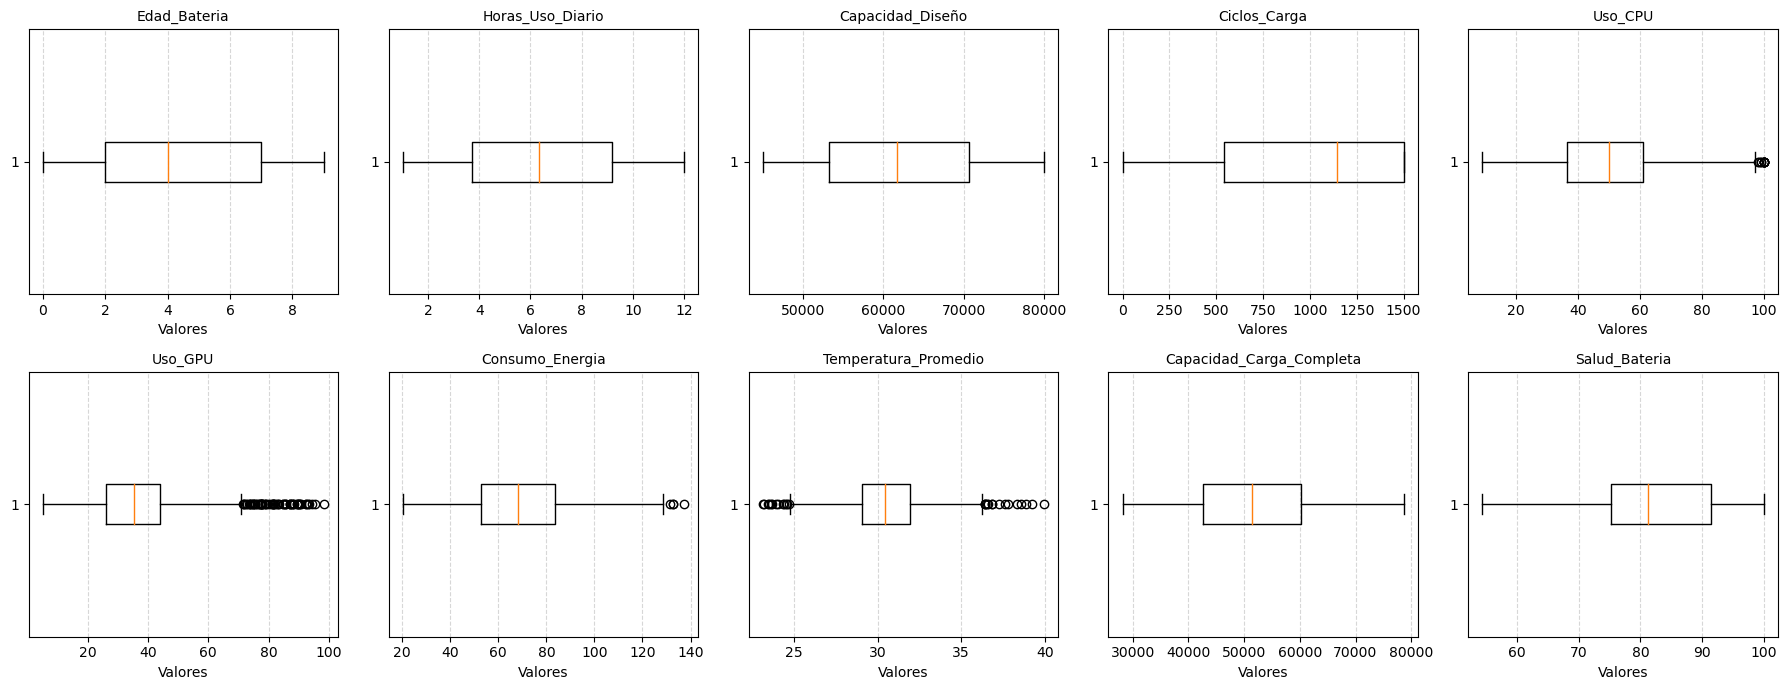

In [24]:
variables = [
    "Edad_Bateria",
    "Horas_Uso_Diario",
    "Capacidad_Diseño",
    "Ciclos_Carga",
    "Uso_CPU",
    "Uso_GPU",
    "Consumo_Energia",
    "Temperatura_Promedio",
    "Capacidad_Carga_Completa",
    "Salud_Bateria"
]

# Crear matriz de gráficos
fig, axes = plt.subplots( nrows=2,ncols=5,figsize=(18, 7))
axes = axes.flatten()
for i, variable in enumerate(variables):
    axes[i].boxplot(df[variable], vert=False)
    axes[i].set_title(variable, fontsize=10)
    axes[i].set_xlabel("Valores")
    axes[i].grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Conclusiones del proceso de limpieza de datos

El proceso de limpieza permitió mejorar la calidad del conjunto de datos, obteniendo un dataset consistente y listo para las etapas posteriores de análisis exploratorio. Durante esta fase se identificaron y trataron los principales problemas de calidad, incluyendo valores faltantes, registros duplicados y valores atípicos.

Los valores faltantes fueron imputados utilizando medidas estadísticas apropiadas para cada variable, preservando la distribución general de los datos y evitando la pérdida de información. Asimismo, los registros duplicados fueron identificados y eliminados para garantizar que cada observación represente un caso único.

En el análisis de valores atípicos se empleó el método del rango intercuartílico (IQR), complementado con una revisión del comportamiento esperado de cada variable. Los valores extremos asociados a errores o inconsistencias fueron corregidos, mientras que aquellos que representan condiciones reales de funcionamiento, como elevados niveles de Uso_CPU, Uso_GPU, Consumo_Energia o Temperatura_Promedio, fueron conservados al considerarse escenarios plausibles de alta exigencia del sistema.

Finalmente, la validación mediante estadísticas descriptivas y representaciones gráficas confirmó que las variables presentan un comportamiento coherente después de la limpieza. Como resultado, el dataset se encuentra preparado para desarrollar el análisis exploratorio de datos (EDA), construir visualizaciones y aplicar técnicas de análisis más avanzadas con mayor confiabilidad.

#### Resumen del proceso de limpieza

| Problema detectado   | Tratamiento aplicado                                                                            | Resultado                                                                       |
| -------------------- | ----------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------- |
| Valores faltantes    | Imputación mediante medidas estadísticas adecuadas para cada variable                           | Dataset completo, sin valores nulos                                             |
| Valores atípicos     | Detección mediante el método IQR y evaluación según el comportamiento esperado de las variables | Se corrigieron valores inconsistentes y se conservaron valores extremos válidos |
| Registros duplicados | Identificación y eliminación de observaciones repetidas                                         | Dataset sin registros duplicados                                                |
| Validación final     | Revisión mediante estadísticas descriptivas y visualizaciones                                   | Dataset consistente y preparado para el análisis exploratorio                   |


In [25]:
print("Dimensiones finales:", df.shape)
print("Valores nulos:", df.isnull().sum().sum())
print("Duplicados:", df.duplicated().sum())

Dimensiones finales: (1210, 11)
Valores nulos: 0
Duplicados: 0


In [26]:
df.to_csv('dataset_limpio_baterias.csv', index=False)